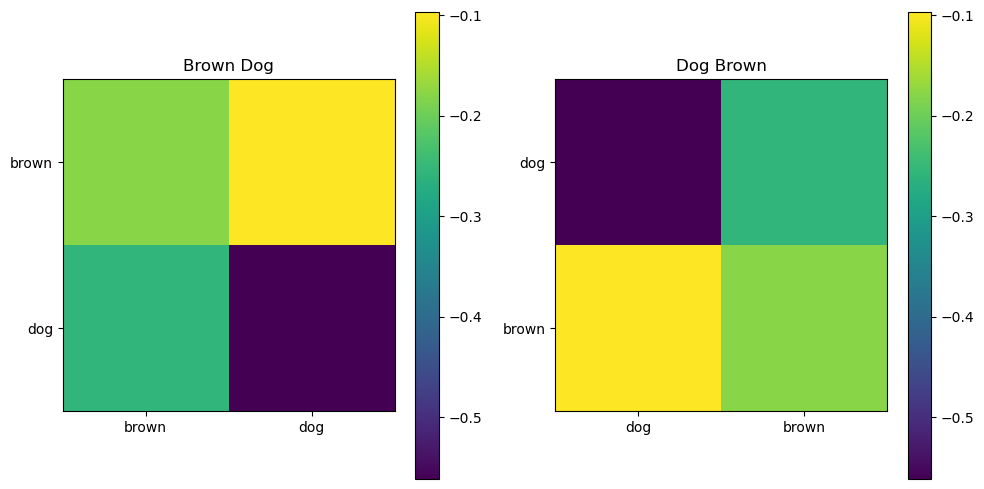

Matrix A (Brown Dog):
 tensor([[-0.1790, -0.0964],
        [-0.2564, -0.5618]], grad_fn=<DivBackward0>)

Matrix B (Dog Brown):
 tensor([[-0.5618, -0.2564],
        [-0.0964, -0.1790]], grad_fn=<DivBackward0>)


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def get_attention_matrix(sentence, model_dim=128):
    # 1. Simple Tokenization (Mapping words to toy IDs)
    vocab = {"brown": 0, "dog": 1}
    tokens = [vocab[w] for w in sentence.split()]
    
    # 2. Initialize Weights (Static for comparison)
    torch.manual_seed(42)
    embedding = torch.nn.Embedding(len(vocab), model_dim)
    pos_embedding = torch.nn.Embedding(10, model_dim) # Absolute pos for simplicity
    
    W_q = torch.nn.Linear(model_dim, model_dim, bias=False)
    W_k = torch.nn.Linear(model_dim, model_dim, bias=False)

    # 3. Embed & Add Position
    indices = torch.tensor(tokens)
    positions = torch.arange(len(tokens))
    
    ''' 
    with postional encoding, the numerical values of the matrix won't be the same 
    but without, it's the same per mathematical calculations 
    '''
    x = embedding(indices) + pos_embedding(positions)
    # x = embedding(indices)
    
    # 4. Compute Q and K
    Q = W_q(x) # [Seq_len, model_dim]
    K = W_k(x) # [Seq_len, model_dim]
    
    # 5. Raw Attention Scores (Q * K.T)
    # We don't use softmax yet so we can see the raw magnitudes
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (model_dim**0.5)
    
    return scores, sentence.split()

# --- Run Experiment ---
score_a, labels_a = get_attention_matrix("brown dog")
score_b, labels_b = get_attention_matrix("dog brown")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, (score, labels, title) in enumerate([
    (score_a, labels_a, "Brown Dog"), 
    (score_b, labels_b, "Dog Brown")
]):
    im = axes[i].imshow(score.detach().numpy(), cmap='viridis')
    axes[i].set_title(title)
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(labels)
    axes[i].set_yticklabels(labels)
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

print("Matrix A (Brown Dog):\n", score_a)
print("\nMatrix B (Dog Brown):\n", score_b)